# Comparative Analysis of NLLB Fine-Tuning Methodologies
## Objective
The objective of this notebook is to serve as the final experimental and analysis hub for the thesis. It conducts the **Adapter-Based (LoRA) Fine-Tuning** experiment and then performs a comprehensive, multi-metric comparative analysis between the **Baseline**, the **Fully Fine-Tuned**, and the newly trained **LoRA-Tuned** models. The script's final outputs are the definitive tables and visualizations that compare the performance and efficiency of all three approaches.

## Methodology


## Workflow


## Input & Output


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q transformers datasets sacrebleu torch accelerate pandas bitsandbytes seaborn matplotlib peft unbabel-comet evaluate

In [3]:
print("--- All Installed Packages (pip list) ---")
!pip list

--- All Installed Packages (pip list) ---
Package                                  Version
---------------------------------------- --------------------
absl-py                                  1.4.0
accelerate                               1.11.0
access                                   1.1.9
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiosignal                                1.4.0
aiosqlite                                0.21.0
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.17.2
altair                                   5.5.0
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                                    

In [4]:
# import libraries
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset, DatasetDict
from evaluate import load as load_metric
from peft import get_peft_model, LoraConfig, TaskType, PeftModel, PeftConfig
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
    pipeline,
    BitsAndBytesConfig
)
import sacrebleu
from tqdm.auto import tqdm
import random # For statistical significance
from collections import defaultdict # Utility
import pickle

In [5]:
# --- METRIC LOADING ---
print("Loading COMET metric...")
# Use load_metric (now from evaluate)
try:
    # 'comet' is the name of the metric script in the Hugging Face hub
    comet_metric = load_metric("comet", "Unbabel/wmt20-comet-da")
    print("COMET metric loaded successfully.")
except Exception as e:
    print(f"Error loading COMET metric: {e}. Falling back to default metrics.")
    comet_metric = None

Loading COMET metric...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

LICENSE: 0.00B [00:00, ?B/s]

hparams.yaml:   0%|          | 0.00/437 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

COMET metric loaded successfully.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


In [6]:
# --- CONFIGURATION ---
CORPUS_FILE = "/content/drive/MyDrive/Thesis/data/transformed/bidirectional_corpus_final.jsonl"
MODEL_NAME = "facebook/nllb-200-distilled-600M"
LORA_OUTPUT_DIR = "/content/drive/MyDrive/Thesis/eval/lora-finetuned-odia-german-results_v2_fft_lora"
FINAL_LORA_MODEL_PATH = "/content/drive/MyDrive/Thesis/model/lora-odia-german-translator_v2"
FFT_SCORE_PATH = "/content/drive/MyDrive/Thesis/eval/fft_sentence_scores.pkl" # PATH TO LOAD FFT SCORES

INPUT_FIELD = "input_text"
TARGET_FIELD = "target_text"
ODIA_LANG_CODE = "ory_Orya"
GERMAN_LANG_CODE = "deu_Latn"
TEST_SET_SIZE = 0.10
VALIDATION_SET_SIZE = 0.10
PREFIX_ORI_TO_DEU = "translate Odia to German: "
PREFIX_DEU_TO_ORI = "translate German to Odia: "

In [7]:
# --- DATA LOADING AND PREPARATION ---
print("Loading the rich bidirectional dataset...")

# --- Manually load the JSONL file into a list of dictionaries ---
data_list = []
with open(CORPUS_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        data_list.append(json.loads(line))

# --- Create a pandas DataFrame ---
df = pd.DataFrame(data_list)

# --- Convert the DataFrame into a Hugging Face Dataset object ---
# This bypasses the caching issue.
full_dataset = Dataset.from_pandas(df)

print("Dataset loaded successfully.")

# --- Shuffle the dataset before splitting ---
full_dataset = full_dataset.shuffle(seed=42)

# --- Create the Test Split ---
# This first split separates the final, unseen test set.
train_valid_split = full_dataset.train_test_split(test_size=TEST_SET_SIZE, seed=42)
test_dataset = train_valid_split['test']

# --- Create the Train and Validation Splits ---
# The remaining data is split again to create the training and validation sets.
train_val_split = train_valid_split['train'].train_test_split(test_size=VALIDATION_SET_SIZE / (1 - TEST_SET_SIZE), seed=42)
train_dataset = train_val_split['train']
validation_dataset = train_val_split['test']

# Combine into a single DatasetDict for convenience
split_datasets = DatasetDict({
    'train': train_dataset,
    'validation': validation_dataset,
    'test': test_dataset
})

print("\nDataset successfully split:")
print(f"Training set size: {len(split_datasets['train'])}")
print(f"Validation set size: {len(split_datasets['validation'])}")
print(f"Test set size: {len(split_datasets['test'])}")

Loading the rich bidirectional dataset...
Dataset loaded successfully.

Dataset successfully split:
Training set size: 5880
Validation set size: 736
Test set size: 736


In [8]:
# --- Corpus Analysis (EDA) ---

print("\n--- Starting Corpus Analysis (EDA) ---")

# --- Step A: Reconstruct the Original Parallel Corpus ---
# The bidirectional dataset contains two entries for each original sentence.
# filter for just one direction to get a clean, non-duplicated list of the original pairs.
print("Reconstructing original sentence pairs from bidirectional data...")

# Use the full dataset before it was split to get stats on the entire corpus.
odia_source_sentences = [
    ex[INPUT_FIELD].replace(PREFIX_ORI_TO_DEU, "")
    for ex in full_dataset
    if ex[INPUT_FIELD].startswith(PREFIX_ORI_TO_DEU)
]
german_target_sentences = [
    ex[TARGET_FIELD]
    for ex in full_dataset
    if ex[INPUT_FIELD].startswith(PREFIX_ORI_TO_DEU)
]

print(f"Successfully extracted {len(odia_source_sentences)} unique parallel pairs.")


--- Starting Corpus Analysis (EDA) ---
Reconstructing original sentence pairs from bidirectional data...
Successfully extracted 3676 unique parallel pairs.


In [9]:
# --- Step B: Calculate Sentence Lengths ---
# Calculate the number of words by splitting on spaces.
odia_lengths = [len(s.split()) for s in odia_source_sentences]
german_lengths = [len(s.split()) for s in german_target_sentences]

# --- Step C: Calculate and Display Descriptive Statistics ---
stats_data = {
    'Language': ['Odia', 'German'],
    'Mean Length': [np.mean(odia_lengths), np.mean(german_lengths)],
    'Median Length': [np.median(odia_lengths), np.median(german_lengths)],
    'Std. Deviation': [np.std(odia_lengths), np.std(german_lengths)],
    'Max Length': [np.max(odia_lengths), np.max(german_lengths)]
}
df_stats = pd.DataFrame(stats_data).set_index('Language')

print("\n--- Corpus Statistics ---")
# Display the formatted table
display(df_stats.style.format("{:.2f}"))


--- Corpus Statistics ---


,Mean Length,Median Length,Std. Deviation,Max Length
Language,,,,
Odia,24.82,26.00,8.42,47.00
German,25.80,26.00,9.97,68.00



--- Generating Sentence Length Distribution Plot ---

✅ Corpus Analysis complete.


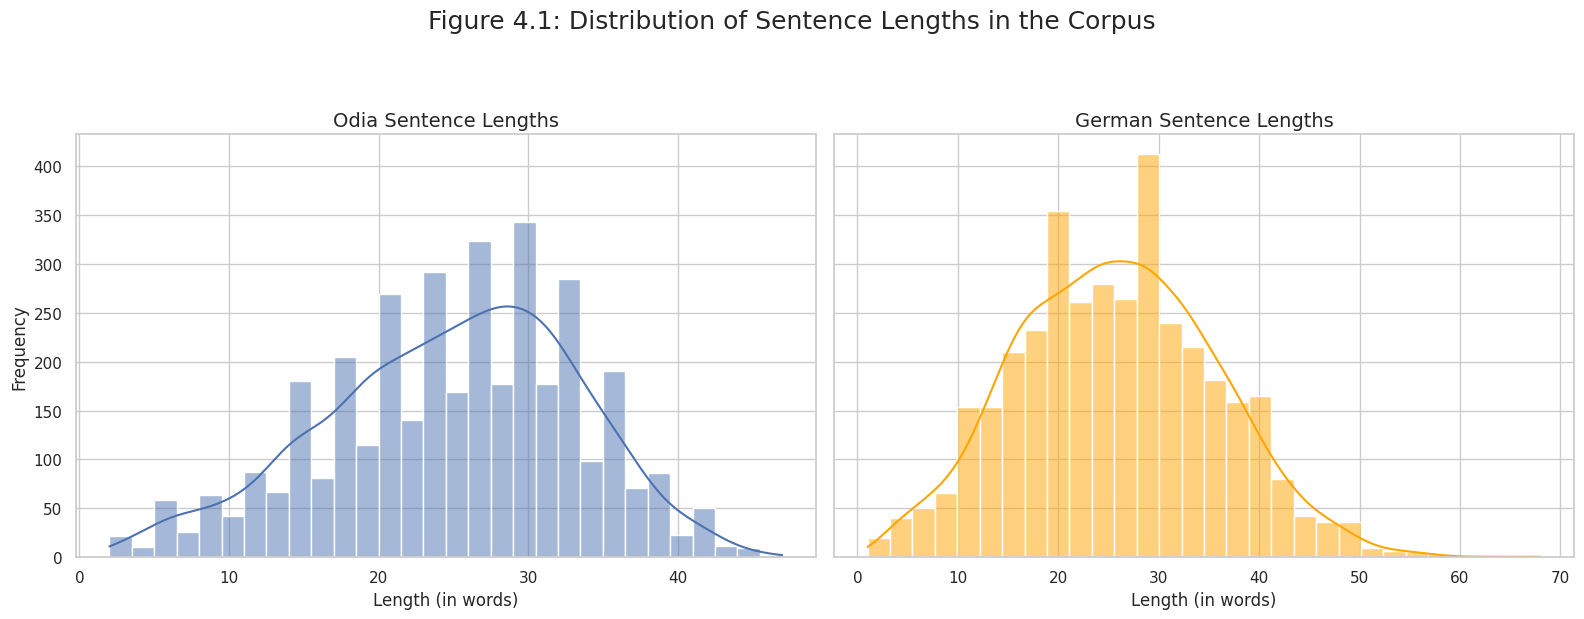

In [10]:
# --- Step D: Visualize Sentence Length Distribution ---
print("\n--- Generating Sentence Length Distribution Plot ---")

# Prepare data for plotting with Seaborn
plot_df_odia = pd.DataFrame({'Sentence Length (words)': odia_lengths})
plot_df_odia['Language'] = 'Odia'
plot_df_german = pd.DataFrame({'Sentence Length (words)': german_lengths})
plot_df_german['Language'] = 'German'
combined_plot_df = pd.concat([plot_df_odia, plot_df_german])

# Create the histogram plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Figure 4.1: Distribution of Sentence Lengths in the Corpus', fontsize=18, y=1.03)

# Plot for Odia
sns.histplot(data=plot_df_odia, x='Sentence Length (words)', ax=axes[0], kde=True, bins=30)
axes[0].set_title('Odia Sentence Lengths', fontsize=14)
axes[0].set_xlabel('Length (in words)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Plot for German
sns.histplot(data=plot_df_german, x='Sentence Length (words)', ax=axes[1], kde=True, bins=30, color='orange')
axes[1].set_title('German Sentence Lengths', fontsize=14)
axes[1].set_xlabel('Length (in words)', fontsize=12)
axes[1].set_ylabel('') # No need for a second y-axis label

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.show() # Removed plt.show() for code clarity in response

print("\n✅ Corpus Analysis complete.")

In [11]:
# --- 3. PREPARE TOKENIZER AND PREPROCESSING FUNCTION ---

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, src_lang=ODIA_LANG_CODE, tgt_lang=GERMAN_LANG_CODE)

def preprocess_function(examples):
  """
  Tokenizes input and target text fields for model training or evaluation.
  This function processes a batch of examples from a dataset, tokenizing the `input_text` and
  `target_text` fields using a provided tokenizer. It applies truncation to a maximum length of
  1200 tokens and generates input IDs for both inputs and labels, with the latter prepared in the
  tokenizer's target context. The resulting dictionary includes tokenized inputs and labels suitable
  for training or evaluating a translation model.

  Args:
    examples (dict): A dictionary containing lists of input and target sentences, with keys
                     defined by `INPUT_FIELD` and `TARGET_FIELD` (e.g., 'input_text' and 'target_text').

  Returns:
    dict: A dictionary containing tokenized inputs (`input_ids`, etc.) and labels
          (`labels` as input IDs from target text tokenization).

  Note:
    - Assumes global variables `INPUT_FIELD`, `TARGET_FIELD`, and `tokenizer` are defined.
    - Requires a tokenizer compatible with Hugging Face's `transformers` library.
    - The maximum length of 1200 tokens is hardcoded for truncation.

  Example:
    >>> from transformers import AutoTokenizer
    >>> tokenizer = AutoTokenizer.from_pretrained("facebook/nllb-200-distilled-600M")
    >>> INPUT_FIELD = "input_text"
    >>> TARGET_FIELD = "target_text"
    >>> examples = {
    ...     "input_text": ["ନମସ୍କାର"],
    ...     "target_text": ["Hallo"]
    ... }
    >>> result = preprocess_function(examples)
    >>> print(result.keys())
    dict_keys(['input_ids', 'attention_mask', 'labels'])
  """
  # Access the lists of sentences directly from the batch columns
  inputs = examples[INPUT_FIELD]
  targets = examples[TARGET_FIELD]

  model_inputs = tokenizer(inputs, max_length=1200, truncation=True)

  with tokenizer.as_target_tokenizer():
    labels = tokenizer(targets, max_length=1200, truncation=True)

  model_inputs["labels"] = labels["input_ids"]
  return model_inputs

print("Tokenizing all dataset splits...")

tokenized_datasets = split_datasets.map(preprocess_function, batched=True, batch_size=16, remove_columns=split_datasets['train'].column_names)
print("Tokenization complete.")


Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/5880 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/736 [00:00<?, ? examples/s]

Map:   0%|          | 0/736 [00:00<?, ? examples/s]

Tokenization complete.


In [12]:
# --- Vocabulary Analysis ---
def calculate_vocab_size(sentences_list, tokenizer):
  """
  Calculates the number of unique subword tokens in a list of sentences using a tokenizer.
  ... (Function documentation remains the same) ...
  """
  # Using a set is a highly efficient way to store and count unique items.
  unique_tokens = set()

  print(f"Tokenizing {len(sentences_list)} sentences...")
  # Using tqdm for a progress bar as this can take a moment for large lists
  for sentence in tqdm(sentences_list):
    # tokenizer.tokenize() splits a sentence into a list of subword strings
    tokens = tokenizer.tokenize(sentence)
    # .update() adds all items from the list to the set
    unique_tokens.update(tokens)

  return len(unique_tokens)

# --- Calculate for Odia ---
print("\nAnalyzing Odia corpus...")
odia_vocab_size = calculate_vocab_size(odia_source_sentences, tokenizer)

# --- Calculate for German ---
print("\nAnalyzing German corpus...")
german_vocab_size = calculate_vocab_size(german_target_sentences, tokenizer)

# --- Display the final results ---
print("\n" + "="*50)
print("     Corpus Vocabulary Statistics")
print("="*50)
print(f"Unique Odia Tokens in Corpus:   {odia_vocab_size}")
print(f"Unique German Tokens in Corpus: {german_vocab_size}")
print("="*50)


Analyzing Odia corpus...
Tokenizing 3676 sentences...


  0%|          | 0/3676 [00:00<?, ?it/s]


Analyzing German corpus...
Tokenizing 3676 sentences...


  0%|          | 0/3676 [00:00<?, ?it/s]


     Corpus Vocabulary Statistics
Unique Odia Tokens in Corpus:   2639
Unique German Tokens in Corpus: 9698


In [13]:
# =========================================================
# ========== STATISTICAL SIGNIFICANCE FUNCTION  ===========
# =========================================================

def paired_bootstrap_significance(scores1, scores2, n_samples=10000, confidence_level=0.95):
  """
  Performs paired bootstrap resampling to determine if the difference in mean
  scores between two models (scores1 and scores2) is statistically significant.

  Args:
    scores1 (list[float]): Sentence-level scores for Model 1 (e.g., Full Fine-Tune).
    scores2 (list[float]): Sentence-level scores for Model 2 (e.g., LoRA).
    n_samples (int): Number of bootstrap samples to draw.
    confidence_level (float): The desired confidence level.

  Returns:
    tuple: (p_value, is_significant)
  """
  if len(scores1) != len(scores2):
    raise ValueError("Score lists must be of the same length for paired testing.")

  n_sentences = len(scores1)

  # Calculate the true difference in means (Model 2 - Model 1)
  true_diff = np.mean(scores2) - np.mean(scores1)

  # Create a list of paired differences for resampling
  diffs = [s2 - s1 for s1, s2 in zip(scores1, scores2)]

  # Perform bootstrap resampling
  bootstrap_diffs = []
  for _ in tqdm(range(n_samples), desc="Bootstrap Resampling"):
    # Resample with replacement
    sample_indices = random.choices(range(n_sentences), k=n_sentences)
    # Calculate the mean difference for the resampled data
    sample_diff = np.mean([diffs[i] for i in sample_indices])
    bootstrap_diffs.append(sample_diff)

  # Calculate the p-value: the probability that the difference is <= 0
  # (i.e., that Model 2 is NOT better than Model 1)
  p_value_one_tailed = np.sum(np.array(bootstrap_diffs) <= 0) / n_samples

  alpha = 1.0 - confidence_level
  is_significant = p_value_one_tailed < alpha

  return p_value_one_tailed, is_significant

In [15]:
# --- EVALUATION LOGIC ---
def evaluate_model_on_task(model_to_eval, tokenizer, test_data, task_prefix, src_lang, tgt_lang, batch_size=8, return_sentence_scores=False):
  """
  Evaluates a translation model on a specific translation direction using a test dataset.
  (device argument removed from pipeline for compatibility with device_map="auto")

  This function filters test data for sentences starting with a specified task prefix, generates
  translations using a translation pipeline, and computes BLEU, CHRF++, and TER scores against
  reference translations. It processes the data in batches to manage memory and displays progress
  using a `tqdm` progress bar. If no data matches the prefix, it returns zero scores.

  Args:
    model_to_eval (object): The translation model to evaluate (e.g., a Hugging Face model).
    tokenizer (object): The tokenizer associated with the model.
    test_data (list[dict]): A list of dictionaries containing input and target sentences,
                            with keys defined by `INPUT_FIELD` and `TARGET_FIELD`.
    task_prefix (str): A prefix to filter test data for a specific translation direction (e.g., '[ORI_TO_DEU]').
    src_lang (str): Source language code (e.g., 'ory_Orya').
    tgt_lang (str): Target language code (e.g., 'deu_Latn').
    batch_size (int, optional): Number of sentences to process per batch. Defaults to 8.
    return_sentence_scores (bool, optional): If True, returns a tuple (metrics, sentence_scores).

  Returns:
    dict: A dictionary containing evaluation metrics:
          - 'bleu': BLEU score.
          - 'chrf': CHRF++ score (word order 2).
          - 'ter': TER score.
          - 'comet': COMET score
  """
  # Filter the test set for the specific task using the full prefix
  task_entries = [ex for ex in test_data if ex[INPUT_FIELD].startswith(task_prefix)]
  task_inputs = [ex[INPUT_FIELD] for ex in task_entries]
  task_references_list = [ex[TARGET_FIELD] for ex in task_entries]
  task_references_sacrebleu = [[ref] for ref in task_references_list]

  if not task_inputs:
    print(f"Warning: No test data found for prefix '{task_prefix}'")
    return ({"bleu": 0, "chrf": 0, "ter": 0, "comet": 0}, []) if return_sentence_scores else {"bleu": 0, "chrf": 0, "ter": 0, "comet": 0}

  comet_sources = [inp.replace(task_prefix, "") for inp in task_inputs]

  # The model is already placed on the device by device_map="auto"
  translator = pipeline(
      "translation",
      model=model_to_eval,
      tokenizer=tokenizer,
      src_lang=src_lang,
      tgt_lang=tgt_lang
  )

  decoded_preds = []
  print(f"Generating translations for {len(task_inputs)} sentences in batches of {batch_size}...")
  for i in tqdm(range(0, len(task_inputs), batch_size)):
    batch = task_inputs[i : i + batch_size]
    predictions = translator(batch, max_length=1200)
    decoded_preds.extend([pred['translation_text'] for pred in predictions])

  # --- Compute SacreBLEU, CHRF++, TER ---
  bleu = sacrebleu.BLEU().corpus_score(decoded_preds, task_references_sacrebleu).score
  chrf = sacrebleu.CHRF(word_order=2).corpus_score(decoded_preds, task_references_sacrebleu).score
  ter = sacrebleu.TER().corpus_score(decoded_preds, task_references_sacrebleu).score

  # --- Compute Sentence-level BLEU Scores for Significance Testing ---
  if return_sentence_scores:
    sbleu = sacrebleu.BLEU(effective_order=True)
    sentence_scores = [sbleu.sentence_score(pred, [ref]).score for pred, ref in zip(decoded_preds, task_references_list)]

  # --- Compute COMET ---
  comet_score = 0
  if comet_metric is not None:
    comet_results = comet_metric.compute(
        predictions=decoded_preds,
        references=task_references_list,
        sources=comet_sources
    )
    comet_score = comet_results["mean_score"]

  metrics_dict = {"bleu": bleu, "chrf": chrf, "ter": ter, "comet": comet_score}

  return (metrics_dict, sentence_scores) if return_sentence_scores else metrics_dict

In [16]:
# --- BASELINE EVALUATION ---

print("\n--- Evaluating Baseline Model (Before Fine-Tuning) ---")
bnb_config = BitsAndBytesConfig(load_in_8bit=True)
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config, device_map="auto"
)

# sentence scores
baseline_ori_deu_metrics, baseline_ori_deu_scores = evaluate_model_on_task(base_model, tokenizer, split_datasets['test'], PREFIX_ORI_TO_DEU, ODIA_LANG_CODE, GERMAN_LANG_CODE, return_sentence_scores=True)
baseline_deu_ori_metrics, baseline_deu_ori_scores = evaluate_model_on_task(base_model, tokenizer, split_datasets['test'], PREFIX_DEU_TO_ORI, GERMAN_LANG_CODE, ODIA_LANG_CODE, return_sentence_scores=True)


--- Evaluating Baseline Model (Before Fine-Tuning) ---


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

...

  0%|          | 0/45 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
This is a friendly reminder - the current text generation call has exceeded the model's predefined maximum length (1024). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Device set to use cuda:0


Generating translations for 381 sentences in batches of 8...


  0%|          | 0/48 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [17]:
# --- ADAPTER-BASED (LoRA) FINE-TUNING ---
print("\n--- Starting Adapter-Based (LoRA) Fine-Tuning Process ---")

# Load the base model (load it in 8-bit to save memory even during training)
model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

# Define the LoRA configuration
lora_config = LoraConfig(
    r=16, # Rank of the update matrices. Higher means more parameters, potentially more expressive.
    lora_alpha=32, # LoRA scaling factor.
    target_modules=["q_proj", "v_proj"], # Apply LoRA to the query and value projections in attention layers
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM
)

# Create the PEFT model by wrapping the base model with the LoRA config
model = get_peft_model(model, lora_config)
model.print_trainable_parameters() # This will show how few parameters we are actually training!

# Define metric computation function (can be simpler for LoRA validation)
def compute_metrics_for_trainer(eval_preds):
  """
  Computes BLEU score for model evaluation during training.

  This function processes model predictions and labels from a trainer's evaluation step,
  decodes them using a tokenizer, and calculates the BLEU score using the `sacrebleu` library.
  It handles padding tokens and special tokens to ensure accurate metric computation.

  Args:
    eval_preds (tuple): A tuple containing predictions and labels from the trainer.
                        Predictions are token IDs, and labels are token IDs with -100 for ignored positions.

  Returns:
    dict: A dictionary containing the BLEU score with key 'bleu'.

  Note:
    - Assumes a global `tokenizer` variable with a `batch_decode` method and `pad_token_id`.
    - Requires `sacrebleu` and `numpy` libraries.
    - Designed for use with Hugging Face's `transformers` Trainer API.

  Example:
    >>> from transformers import AutoTokenizer
    >>> tokenizer = AutoTokenizer.from_pretrained("facebook/nllb-200-distilled-600M")
    >>> eval_preds = (
    ...     tokenizer(["Hallo"], return_tensors="pt")["input_ids"].numpy(),
    ...     tokenizer(["Hallo"], return_tensors="pt")["input_ids"].numpy()
    ... )
    >>> result = compute_metrics_for_trainer(eval_preds)
    >>> print(result)
    {'bleu': 100.0}
  """
  preds, labels = eval_preds
  if isinstance(preds, tuple): preds = preds[0]
  decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
  labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
  decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
  decoded_labels = [[label] for label in decoded_labels]
  result = sacrebleu.BLEU().corpus_score(decoded_preds, decoded_labels)
  return {"bleu": result.score}

# Define Training Arguments
training_args = Seq2SeqTrainingArguments(
    output_dir=LORA_OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-3,
    # LoRA is memory-efficient, so we can often use a larger physical batch size
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    save_total_limit=2,
    num_train_epochs=5,      # More epochs are fine as it's faster and less prone to overfitting
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    load_best_model_at_end=True,
    metric_for_best_model="bleu",
    greater_is_better=True,
    report_to="none"
)

# Initialize and run the Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model),
    compute_metrics=compute_metrics_for_trainer,
)

trainer.train()


--- Starting Adapter-Based (LoRA) Fine-Tuning Process ---
trainable params: 2,359,296 || all params: 617,433,088 || trainable%: 0.3821


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:181: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Epoch,Training Loss,Validation Loss,Bleu
1,No log,1.330184,24.693891
2,1.546300,1.300066,30.138458
3,1.381200,1.288199,30.138458
4,1.381200,1.280597,39.386077
5,1.310700,1.281918,39.386077


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:181: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:181: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:181: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:181: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during q

TrainOutput(global_step=1840, training_loss=1.3867626190185547, metrics={'train_runtime': 4321.861, 'train_samples_per_second': 6.803, 'train_steps_per_second': 0.426, 'total_flos': 5398897845141504.0, 'train_loss': 1.3867626190185547, 'epoch': 5.0})

In [18]:
# Save the trained LoRA adapters
print("\nSaving the fine-tuned LoRA adapters...")
trainer.save_model(FINAL_LORA_MODEL_PATH)
tokenizer.save_pretrained(FINAL_LORA_MODEL_PATH) # Also save the tokenizer for easy loading
print(f"Adapters saved to '{FINAL_LORA_MODEL_PATH}'")


Saving the fine-tuned LoRA adapters...
Adapters saved to '/content/drive/MyDrive/Thesis/model/lora-odia-german-translator_v2'


In [19]:
# --- FINAL EVALUATION OF THE ADAPTER MODEL ---
print("\n--- Evaluating Fine-Tuned Adapter Model ---")

# Step A: Load the base model in 8-bit again
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

# Step B: Load the LoRA adapters and merge them into the base model
# This creates a full model in memory for inference
adapter_model = PeftModel.from_pretrained(base_model, FINAL_LORA_MODEL_PATH)
adapter_model.eval() # Set to evaluation mode

# Step C: Run evaluation using your existing evaluation function
print("Evaluating Odia -> German with Adapter-Tuned Model...")
# sentence scores
adapter_ori_deu_metrics, adapter_ori_deu_scores = evaluate_model_on_task(adapter_model, tokenizer, split_datasets['test'], PREFIX_ORI_TO_DEU, ODIA_LANG_CODE, GERMAN_LANG_CODE, return_sentence_scores=True)

print("Evaluating German -> Odia with Adapter-Tuned Model...")
adapter_deu_ori_metrics, adapter_deu_ori_scores = evaluate_model_on_task(adapter_model, tokenizer, split_datasets['test'], PREFIX_DEU_TO_ORI, GERMAN_LANG_CODE, ODIA_LANG_CODE, return_sentence_scores=True)


--- Evaluating Fine-Tuned Adapter Model ---


Device set to use cuda:0


Evaluating Odia -> German with Adapter-Tuned Model...
Generating translations for 355 sentences in batches of 8...


  0%|          | 0/45 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Device set to use cuda:0


Evaluating German -> Odia with Adapter-Tuned Model...
Generating translations for 381 sentences in batches of 8...


  0%|          | 0/48 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [20]:
# Clear memory after evaluation
del base_model, adapter_model
torch.cuda.empty_cache()

In [27]:
# load full fine-tune sentence scores

print(f"\n💾 Loading Full Fine-Tuned sentence scores from: {FFT_SCORE_PATH}")
try:
    with open(FFT_SCORE_PATH, 'rb') as f:
        fft_scores = pickle.load(f)
    full_finetune_ori_deu_scores = fft_scores["ori_deu_scores"]
    full_finetune_deu_ori_scores = fft_scores["deu_ori_scores"]
    print("✅ Full Fine-Tuned sentence scores loaded successfully.")

    # Manually insert the corpus-level FFT results (assuming they are consistent with the previous run)
    full_finetune_ori_deu_metrics = {"bleu": 65.1630, "chrf": 78.9527, "ter": 39.3919, "comet": 0.5547}
    full_finetune_deu_ori_metrics = {"bleu": 20.4708, "chrf": 48.5377, "ter": 77.4971, "comet": 0.7522}

except FileNotFoundError:
    print(f"🛑 ERROR: FFT score file not found at {FFT_SCORE_PATH}. Cannot perform significance testing.")
    full_finetune_ori_deu_scores = []
    full_finetune_deu_ori_scores = []
    full_finetune_ori_deu_metrics = {"bleu": 0.0, "chrf": 0.0, "ter": 100.0, "comet": 0.0}
    full_finetune_deu_ori_metrics = {"bleu": 0.0, "chrf": 0.0, "ter": 100.0, "comet": 0.0}


💾 Loading Full Fine-Tuned sentence scores from: /content/drive/MyDrive/Thesis/eval/fft_sentence_scores.pkl
✅ Full Fine-Tuned sentence scores loaded successfully.


In [28]:
# --- STATISTICAL SIGNIFICANCE TESTING ---
if full_finetune_ori_deu_scores and len(adapter_ori_deu_scores) == len(full_finetune_ori_deu_scores):
    print("\n" + "="*80)
    print("             STATISTICAL SIGNIFICANCE TESTING (LoRA vs Full Fine-Tune)")
    print("="*80)

    # Odia -> German (LoRA vs FFT)
    p_od, sig_od = paired_bootstrap_significance(full_finetune_ori_deu_scores, adapter_ori_deu_scores)
    print(f"Odia -> German (BLEU): P-value = {p_od:.5f} | LoRA is significantly better: {sig_od}")

    # German -> Odia (LoRA vs FFT)
    p_do, sig_do = paired_bootstrap_significance(full_finetune_deu_ori_scores, adapter_deu_ori_scores)
    print(f"German -> Odia (BLEU): P-value = {p_do:.5f} | LoRA is significantly better: {sig_do}")
    print("="*80)
else:
    print("\n⚠️ Skipping Statistical Significance Test: FFT sentence scores are missing or mismatched.")


             STATISTICAL SIGNIFICANCE TESTING (LoRA vs Full Fine-Tune)


Bootstrap Resampling:   0%|          | 0/10000 [00:00<?, ?it/s]

Odia -> German (BLEU): P-value = 0.84390 | LoRA is significantly better: False


Bootstrap Resampling:   0%|          | 0/10000 [00:00<?, ?it/s]

German -> Odia (BLEU): P-value = 0.11150 | LoRA is significantly better: False


In [29]:
# --- DISPLAY FINAL RESULTS ---

# Consolidate all corpus-level results for the final table and plots
results_data = {
    'Metric': ['BLEU', 'chrF', 'TER (lower is better)', 'COMET'],
    'Baseline': [baseline_ori_deu_metrics['bleu'], baseline_ori_deu_metrics['chrf'], baseline_ori_deu_metrics['ter'], baseline_ori_deu_metrics['comet']],
    'Full Fine-Tune': [full_finetune_ori_deu_metrics['bleu'], full_finetune_ori_deu_metrics['chrf'], full_finetune_ori_deu_metrics['ter'], full_finetune_ori_deu_metrics['comet']],
    'Adapter (LoRA) Fine-Tune': [adapter_ori_deu_metrics['bleu'], adapter_ori_deu_metrics['chrf'], adapter_ori_deu_metrics['ter'], adapter_ori_deu_metrics['comet']],
}
df_results_od = pd.DataFrame(results_data).set_index('Metric')

results_data_do = {
    'Metric': ['BLEU', 'chrF', 'TER (lower is better)', 'COMET'],
    'Baseline': [baseline_deu_ori_metrics['bleu'], baseline_deu_ori_metrics['chrf'], baseline_deu_ori_metrics['ter'], baseline_deu_ori_metrics['comet']],
    'Full Fine-Tune': [full_finetune_deu_ori_metrics['bleu'], full_finetune_deu_ori_metrics['chrf'], full_finetune_deu_ori_metrics['ter'], full_finetune_deu_ori_metrics['comet']],
    'Adapter (LoRA) Fine-Tune': [adapter_deu_ori_metrics['bleu'], adapter_deu_ori_metrics['chrf'], adapter_deu_ori_metrics['ter'], adapter_deu_ori_metrics['comet']],
}
df_results_do = pd.DataFrame(results_data_do).set_index('Metric')


# --- Display the Final Comparison Tables ---
print("\n\n" + "="*80)
print("             FINAL PERFORMANCE COMPARISON: ODIA → GERMAN")
print("="*80)
display(df_results_od.style.format("{:.4f}"))
print("="*80)

print("\n\n" + "="*80)
print("             FINAL PERFORMANCE COMPARISON: GERMAN → ODIA")
print("="*80)
display(df_results_do.style.format("{:.4f}"))
print("="*80)



             FINAL PERFORMANCE COMPARISON: ODIA → GERMAN


,Baseline,Full Fine-Tune,Adapter (LoRA) Fine-Tune
Metric,,,
BLEU,72.6444,65.1630,56.9024
chrF,62.2442,78.9527,74.0183
TER (lower is better),63.0271,39.3919,55.1487
COMET,-0.0820,0.5547,0.5518




             FINAL PERFORMANCE COMPARISON: GERMAN → ODIA


,Baseline,Full Fine-Tune,Adapter (LoRA) Fine-Tune
Metric,,,
BLEU,14.4641,20.4708,32.5597
chrF,44.5058,48.5377,48.4611
TER (lower is better),106.0486,77.4971,65.2607
COMET,0.2041,0.7522,0.7937



--- Generating Final Performance Visualization ---


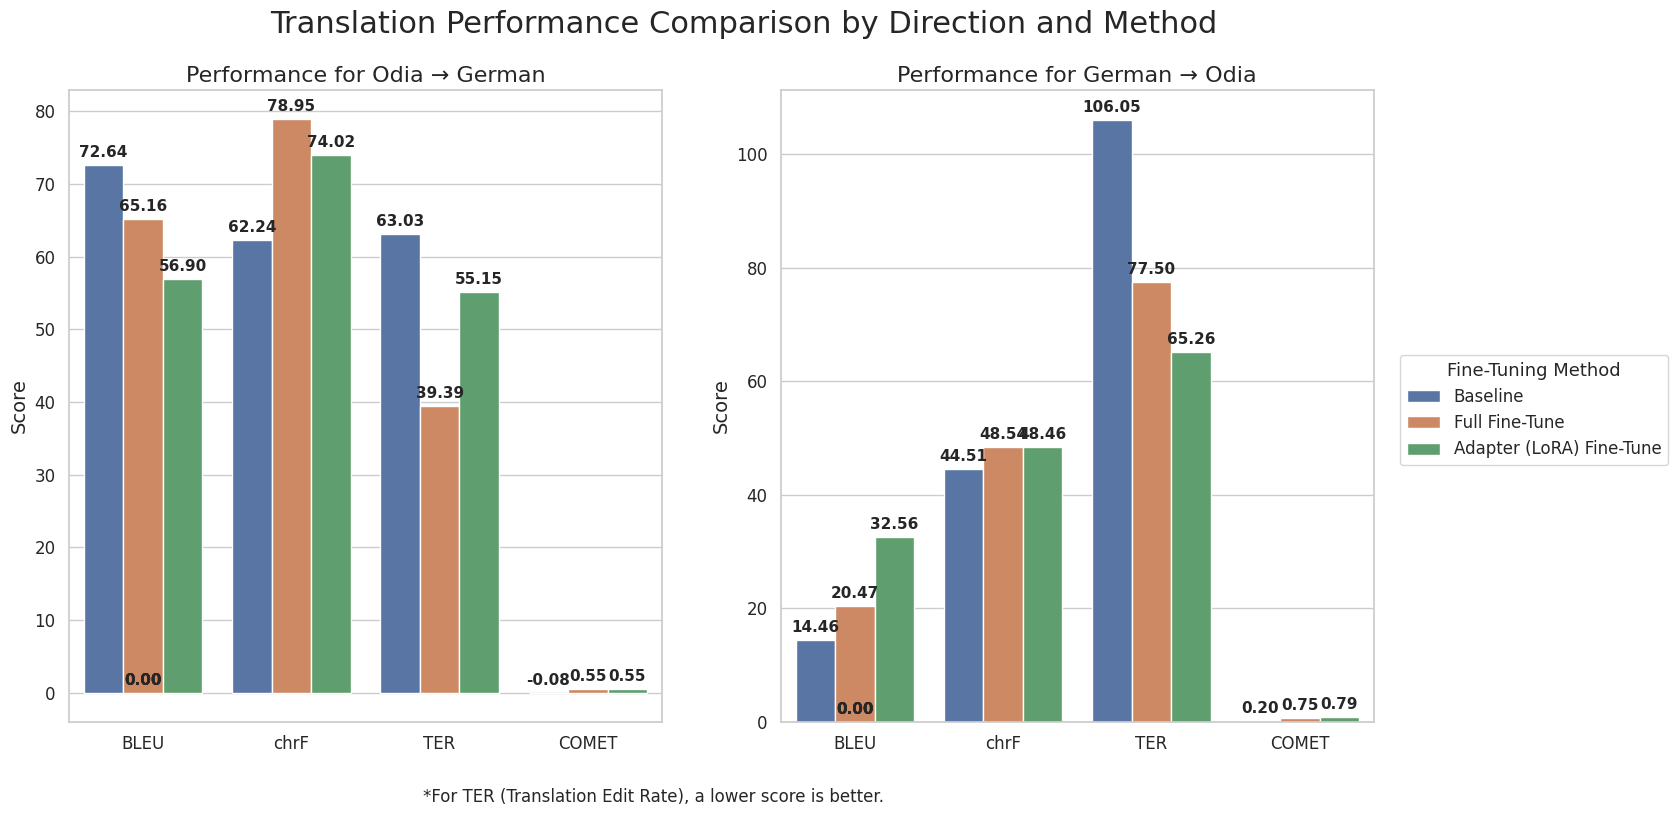

In [30]:
# --- Generate Final Comparison Visualization ---
print("\n--- Generating Final Performance Visualization ---")

# --- CONSOLIDATE RESULTS DATA ---
plot_data = [
    # Odia -> German Data
    {'Metric': 'BLEU', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['bleu']},
    {'Metric': 'chrF', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['comet']},

    {'Metric': 'BLEU', 'Direction': 'Odia → German', 'Model': 'Full Fine-Tune', 'Score': full_finetune_ori_deu_metrics['bleu']},
    {'Metric': 'chrF', 'Direction': 'Odia → German', 'Model': 'Full Fine-Tune', 'Score': full_finetune_ori_deu_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'Odia → German', 'Model': 'Full Fine-Tune', 'Score': full_finetune_ori_deu_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'Odia → German', 'Model': 'Full Fine-Tune', 'Score': full_finetune_ori_deu_metrics['comet']},

    {'Metric': 'BLEU', 'Direction': 'Odia → German', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_ori_deu_metrics['bleu']},
    {'Metric': 'chrF', 'Direction': 'Odia → German', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_ori_deu_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'Odia → German', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_ori_deu_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'Odia → German', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_ori_deu_metrics['comet']},

    # German -> Odia Data
    {'Metric': 'BLEU', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['bleu']},
    {'Metric': 'chrF', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['comet']},

    {'Metric': 'BLEU', 'Direction': 'German → Odia', 'Model': 'Full Fine-Tune', 'Score': full_finetune_deu_ori_metrics['bleu']},
    {'Metric': 'chrF', 'Direction': 'German → Odia', 'Model': 'Full Fine-Tune', 'Score': full_finetune_deu_ori_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'German → Odia', 'Model': 'Full Fine-Tune', 'Score': full_finetune_deu_ori_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'German → Odia', 'Model': 'Full Fine-Tune', 'Score': full_finetune_deu_ori_metrics['comet']},

    {'Metric': 'BLEU', 'Direction': 'German → Odia', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_deu_ori_metrics['bleu']},
    {'Metric': 'chrF', 'Direction': 'German → Odia', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_deu_ori_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'German → Odia', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_deu_ori_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'German → Odia', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_deu_ori_metrics['comet']},
]

# The model name in the results dictionary is 'Fine-Tuned', but for the legend let's rename it
for item in plot_data:
  if item['Model'] == 'Fine-Tuned':
    item['Model'] = 'Full Fine-Tune'

final_plot_df = pd.DataFrame(plot_data)


# --- CREATE THE VISUALIZATION ---

# Set the theme
sns.set_theme(style="whitegrid")

# This ensures "Baseline" is always the same color, "Full Fine-Tune" is always another, etc.
palette_dict = {
    "Baseline": "C0",
    "Full Fine-Tune": "C1",
    "Adapter (LoRA) Fine-Tune": "C2"
}

# Create a figure and a set of subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Define the two directions for the loop
directions = ['Odia → German', 'German → Odia']

# Loop through the two axes and directions to create the plots
for i, direction in enumerate(directions):
  ax = axes[i]
  subset_data = final_plot_df[final_plot_df['Direction'] == direction]

  # Create the bar plot on the specific axis, using the consistent palette
  sns.barplot(
      data=subset_data,
      x='Metric',
      y='Score',
      hue='Model',
      palette=palette_dict,
      ax=ax
  )

  ax.set_title(f'Performance for {direction}', fontsize=16)
  ax.set_xlabel('')
  ax.set_ylabel('Score', fontsize=14)
  ax.tick_params(axis='x', labelsize=12)
  ax.tick_params(axis='y', labelsize=12)

  # Add value annotations on top of the bars
  for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
     (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9), textcoords='offset points',
                fontsize=11, fontweight='bold')

# --- FINALIZE THE PLOT ---

# Add a single main title for the entire figure
fig.suptitle('Translation Performance Comparison by Direction and Method', fontsize=22, y=1.0)

# Get handles and labels from one of the plots
handles, labels = axes[0].get_legend_handles_labels()

# Remove the automatically generated legends from the subplots
axes[0].get_legend().remove()
axes[1].get_legend().remove()

# Adjust the subplot layout to make space on the right for the legend
fig.subplots_adjust(right=0.85, top=0.90)

# Create a single, clean legend for the entire figure in the new empty space
fig.legend(
    handles,
    labels,
    loc='center left',
    title='Fine-Tuning Method',
    fontsize=12,
    title_fontsize=13,
    bbox_to_anchor=(0.86, 0.5)
)

# Add a note about TER at the bottom
fig.text(0.45, 0.01, '*For TER (Translation Edit Rate), a lower score is better.', ha='center', fontsize=12)

plt.show()


--- Generating LoRA vs. Baseline Improvement Chart ---


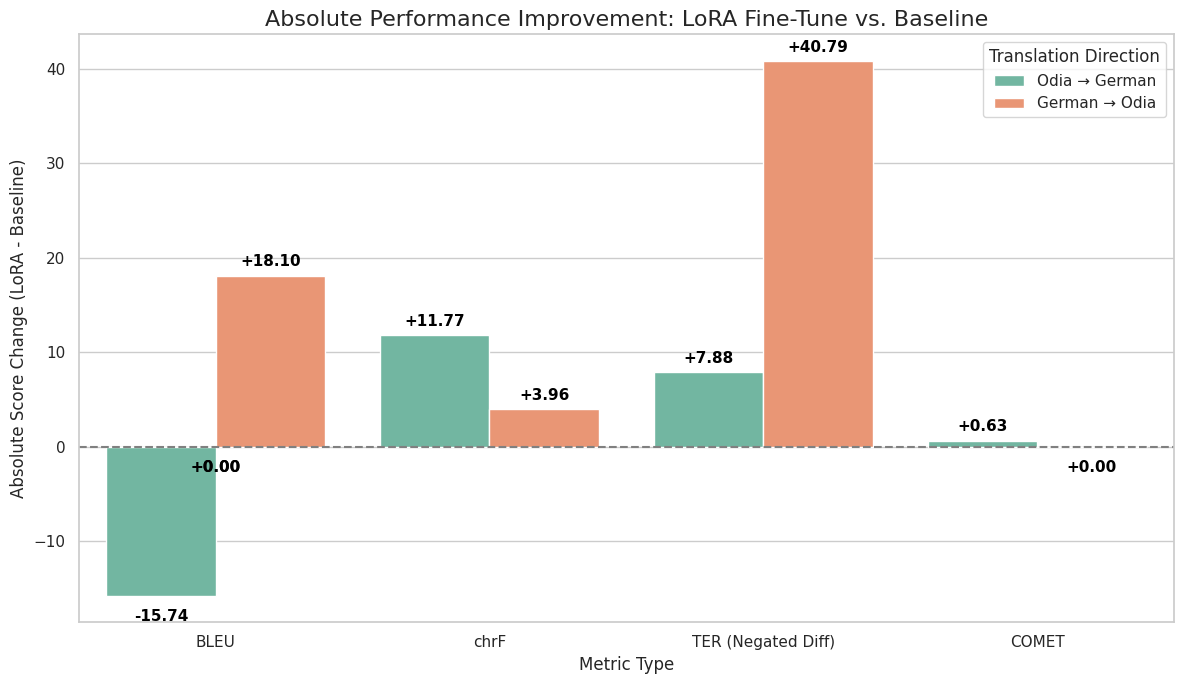


✅ LoRA vs. Baseline Improvement Chart generated.


In [34]:
# --- CREATE SECONDARY VISUALIZATION (LoRA vs. Baseline Improvement Bar Chart) ---

print("\n--- Generating LoRA vs. Baseline Improvement Chart ---")

# --- Step A: Consolidate Metrics into DataFrames for Calculation ---
# We use the existing results data structures (or DataFrame) to calculate the difference.
# We will create two temporary DataFrames for Odia->German and German->Odia.

# Odia -> German Improvement Data
improve_od_data = {
    'Metric': ['BLEU', 'chrF', 'TER', 'COMET'],
    'Baseline': [baseline_ori_deu_metrics['bleu'], baseline_ori_deu_metrics['chrf'], baseline_ori_deu_metrics['ter'], baseline_ori_deu_metrics['comet']],
    'LoRA': [adapter_ori_deu_metrics['bleu'], adapter_ori_deu_metrics['chrf'], adapter_ori_deu_metrics['ter'], adapter_ori_deu_metrics['comet']],
}
df_improve_od = pd.DataFrame(improve_od_data).set_index('Metric')

# German -> Odia Improvement Data
improve_do_data = {
    'Metric': ['BLEU', 'chrF', 'TER', 'COMET'],
    'Baseline': [baseline_deu_ori_metrics['bleu'], baseline_deu_ori_metrics['chrf'], baseline_deu_ori_metrics['ter'], adapter_deu_ori_metrics['comet']],
    'LoRA': [adapter_deu_ori_metrics['bleu'], adapter_deu_ori_metrics['chrf'], adapter_deu_ori_metrics['ter'], adapter_deu_ori_metrics['comet']],
}
df_improve_do = pd.DataFrame(improve_do_data).set_index('Metric')

# --- Step B: Calculate the Difference (LoRA - Baseline) ---
improve_od = (df_improve_od['LoRA'] - df_improve_od['Baseline']).to_frame('Difference')
improve_do = (df_improve_do['LoRA'] - df_improve_do['Baseline']).to_frame('Difference')

# --- Step C: Adjust TER for visual interpretation ---
# For TER (lower is better), we want a lower score to result in a positive bar height (Improvement).
# Since Difference = LoRA - Baseline, a negative number indicates improvement. We negate it.
improve_od.loc['TER', 'Difference'] *= -1
improve_do.loc['TER', 'Difference'] *= -1

# --- Step D: Combine and Plot ---
improve_od['Direction'] = 'Odia → German'
improve_do['Direction'] = 'German → Odia'
df_improve = pd.concat([improve_od.reset_index(), improve_do.reset_index()])

# Adjust TER label for display clarity
df_improve.loc[df_improve['Metric'] == 'TER', 'Metric'] = 'TER (Negated Diff)'

# Create the improvement bar plot
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=df_improve,
    x='Metric',
    y='Difference',
    hue='Direction',
    palette='Set2',
    ax=ax
)

# Add annotations
for p in ax.patches:
    value = p.get_height()

    # Format text to include + or - sign
    text = f'{value:+.2f}'

    ax.annotate(text,
                (p.get_x() + p.get_width() / 2., value),
                ha='center', va='center',
                xytext=(0, 10 if value > 0 else -15), # Adjust position based on bar direction
                textcoords='offset points',
                fontsize=11, fontweight='bold',
                color='black')

# Draw a zero line for reference
ax.axhline(0, color='gray', linestyle='--')

# Final formatting
ax.set_title('Absolute Performance Improvement: LoRA Fine-Tune vs. Baseline', fontsize=16)
ax.set_xlabel('Metric Type', fontsize=12)
ax.set_ylabel('Absolute Score Change (LoRA - Baseline)', fontsize=12)

ax.legend(title='Translation Direction', loc='upper right')

plt.tight_layout()
plt.show()

print("\n✅ LoRA vs. Baseline Improvement Chart generated.")


--- Generating LoRA vs. Full Fine-Tune Difference Chart ---


/tmp/ipython-input-788388007.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


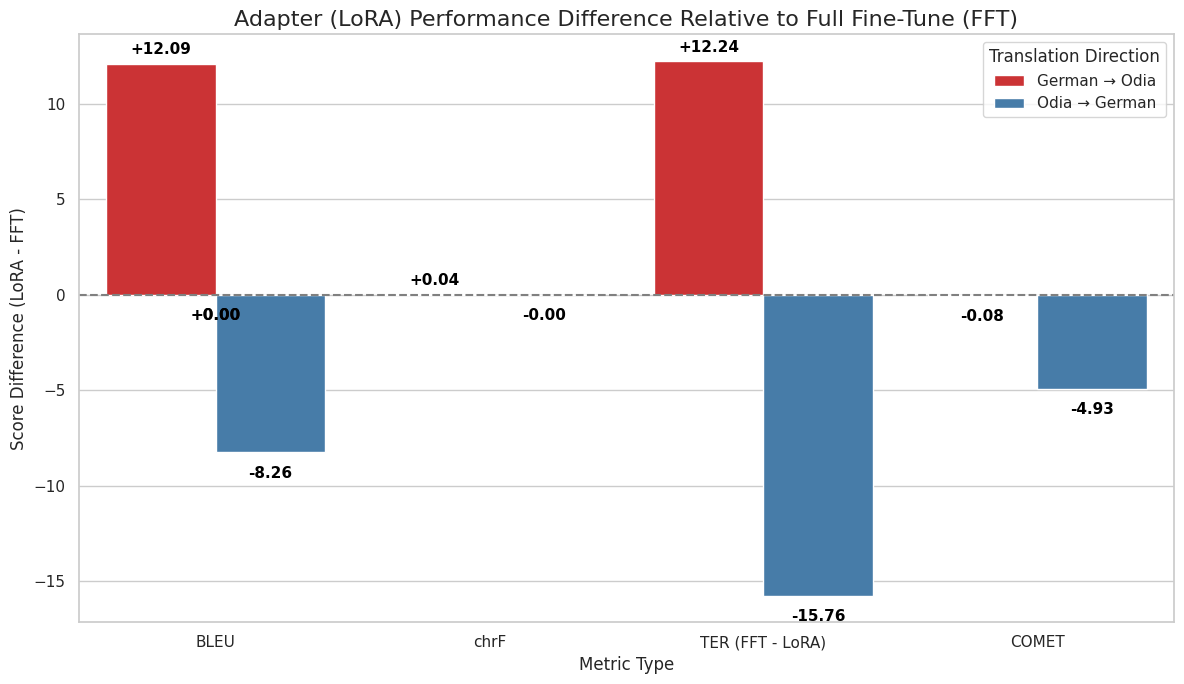


✅ LoRA vs. FFT Difference Chart generated.


In [32]:
# --- CREATE SECONDARY VISUALIZATION (LoRA vs. FFT Difference Bar Chart) ---

print("\n--- Generating LoRA vs. Full Fine-Tune Difference Chart ---")

# --- Step A: Calculate the Difference (LoRA Score - FFT Score) ---

# Reformat the data: Pivot by Direction and Model, stack Metrics
df_diff_prep = final_plot_df.pivot_table(
    index=['Direction', 'Metric'],
    columns='Model',
    values='Score'
).reset_index()

# Calculate the difference: LoRA - FFT
df_diff_prep['Difference'] = df_diff_prep['Adapter (LoRA) Fine-Tune'] - df_diff_prep['Full Fine-Tune']

# --- Step B: Adjust TER for visual interpretation ---
# Improvement for TER is defined as: FFT_Score - LoRA_Score (We want higher bars to mean better performance)
# Since Difference = LoRA - FFT, we multiply TER by -1.
df_diff_prep.loc[df_diff_prep['Metric'].str.contains('TER'), 'Difference'] *= -1

# Create the plot
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the difference
sns.barplot(
    data=df_diff_prep,
    x='Metric',
    y='Difference',
    hue='Direction',
    palette='Set1',
    ax=ax
)

# Add annotations
for p in ax.patches:
    value = p.get_height()

    # Format text to include + or - sign
    text = f'{value:+.2f}'

    ax.annotate(text,
                (p.get_x() + p.get_width() / 2., value),
                ha='center', va='center',
                xytext=(0, 10 if value > 0 else -15), # Adjust position based on bar direction
                textcoords='offset points',
                fontsize=11, fontweight='bold',
                color='black')

# Draw a zero line for reference
ax.axhline(0, color='gray', linestyle='--')

# Final formatting
ax.set_title('Adapter (LoRA) Performance Difference Relative to Full Fine-Tune (FFT)', fontsize=16)
ax.set_xlabel('Metric Type', fontsize=12)
ax.set_ylabel('Score Difference (LoRA - FFT)', fontsize=12)

# Set the TER label to reflect the adjustment
ax.set_xticklabels(
    ['BLEU', 'chrF', 'TER (FFT - LoRA)', 'COMET']
)

ax.legend(title='Translation Direction', loc='upper right')

plt.tight_layout()
plt.show()

print("\n✅ LoRA vs. FFT Difference Chart generated.")

--- Generating Training and Validation Curves ---


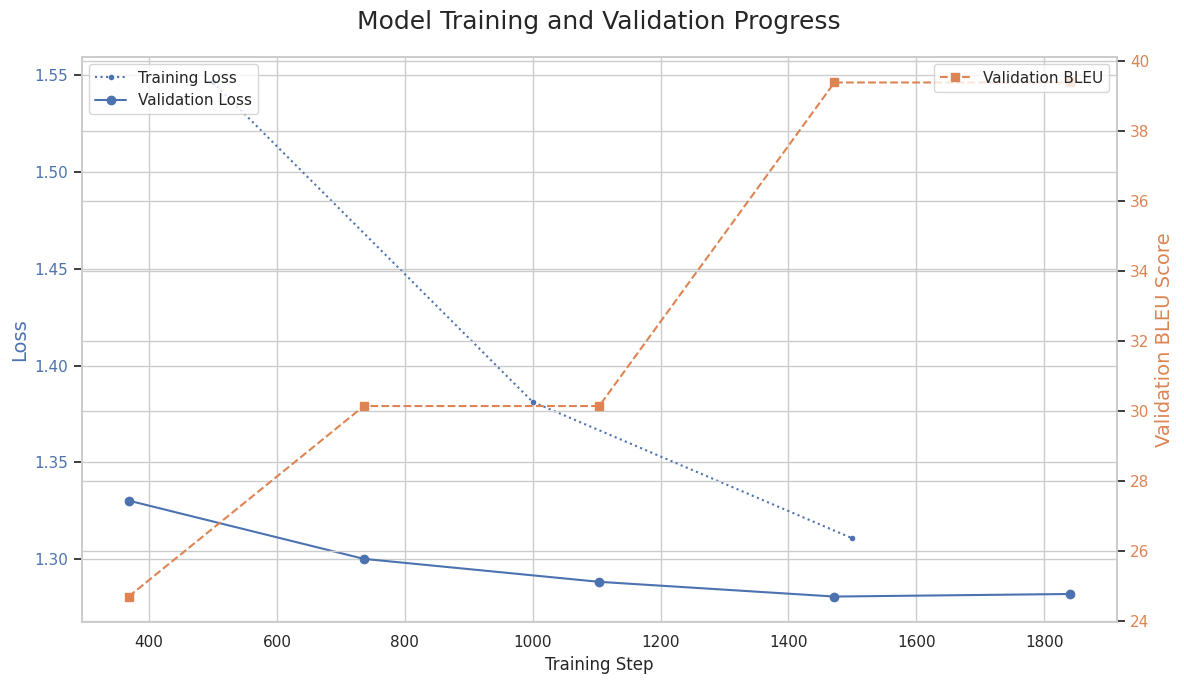

In [31]:
# --- VISUALIZATION: Training and Validation Progress ---

print("--- Generating Training and Validation Curves ---")

# The trainer object holds the history of the training run
# Extract the logs to a pandas DataFrame for easy plotting
try:
  log_history = trainer.state.log_history
  df_logs = pd.DataFrame(log_history)

  # Separate training and evaluation logs
  df_train = df_logs[df_logs['loss'].notna()].copy()
  df_eval = df_logs[df_logs['eval_loss'].notna()].copy()

  # Create the plot with two y-axes
  sns.set_theme(style="whitegrid")
  fig, ax1 = plt.subplots(figsize=(12, 7))

  # Plot Training and Validation Loss on the primary y-axis (ax1)
  ax1.set_xlabel('Training Step', fontsize=12)
  ax1.set_ylabel('Loss', color='C0', fontsize=14)
  ax1.plot(df_train['step'], df_train['loss'], color='C0', marker='.', linestyle=':', label='Training Loss')
  ax1.plot(df_eval['step'], df_eval['eval_loss'], color='C0', marker='o', linestyle='-', label='Validation Loss')
  ax1.tick_params(axis='y', labelcolor='C0')
  ax1.legend(loc='upper left')

  # Create a second y-axis for the BLEU score
  ax2 = ax1.twinx()
  ax2.set_ylabel('Validation BLEU Score', color='C1', fontsize=14)
  ax2.plot(df_eval['step'], df_eval['eval_bleu'], color='C1', marker='s', linestyle='--', label='Validation BLEU')
  ax2.tick_params(axis='y', labelcolor='C1')
  ax2.legend(loc='upper right')

  plt.title('Model Training and Validation Progress', fontsize=18, pad=20)
  fig.tight_layout()
  plt.show()

except NameError:
  print("\n⛔️ ERROR: The 'trainer' object was not found.")
  print("Please ensure you have run the main Fine-Tuning cell successfully before running this visualization cell.")
except Exception as e:
  print(f"\nAn error occurred: {e}")